# Customer Churn Prediction Using Machine Learning

## Business Problem

Customer churn merupakan kondisi ketika pelanggan berhenti menggunakan suatu layanan. Kemampuan untuk mengidentifikasi pelanggan yang berpotensi churn dapat membantu perusahaan dalam menyusun strategi retensi pelanggan.

Pada project ini, Machine Learning digunakan untuk memprediksi apakah seorang pelanggan akan mengalami churn berdasarkan karakteristik pelanggan, layanan yang digunakan, jenis kontrak, lama berlangganan, serta informasi biaya.

Project ini dilakukan secara end-to-end, mulai dari data loading, data understanding, data cleaning, exploratory data analysis, feature engineering, preprocessing, pengembangan model, evaluasi, interpretasi model, hingga simulasi prediksi customer baru.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Loading

Tahap pertama adalah menghubungkan Google Colab dengan Google Drive dan memuat dataset Telco Customer Churn.

Dataset berisi informasi mengenai karakteristik pelanggan dan status churn. Pemeriksaan awal dilakukan untuk mengetahui ukuran dan beberapa baris pertama dataset.

In [7]:
import pandas as pd
file_path = '/content/drive/MyDrive/Project/Data/Telco-Customer-Churn.csv'

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()



Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Understanding

Tahap Data Understanding bertujuan mengetahui kondisi awal dataset sebelum pemodelan.

Pemeriksaan meliputi jumlah observasi dan variabel, tipe data, missing value, serta data duplikat. Hasil pemeriksaan digunakan untuk menentukan langkah data cleaning yang diperlukan.

In [8]:
# Informasi dasar dataset
print("=== DATASET INFO ===")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")

print("\n=== TIPE DATA ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Jumlah duplicate : {df.duplicated().sum()}")

=== DATASET INFO ===
Jumlah baris  : 7,043
Jumlah kolom  : 21

=== TIPE DATA ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
Streami

## 3. Data Cleaning — Identifikasi `TotalCharges`

Variabel `TotalCharges` secara konsep merupakan variabel numerik, tetapi pada data awal terbaca sebagai `object`.

Pada tahap ini nilai yang tidak dapat dikonversi ke numerik diidentifikasi terlebih dahulu. Hal ini penting agar permasalahan data tidak langsung ditangani tanpa mengetahui bentuk nilai yang bermasalah.

In [5]:
# Cek nilai TotalCharges yang tidak bisa dikonversi ke numerik

total_charges_numeric = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Jumlah nilai yang menjadi NaN setelah konversi:",
      total_charges_numeric.isna().sum())

print("\nNilai yang tidak bisa dikonversi:")
print(df.loc[total_charges_numeric.isna(), 'TotalCharges'].unique())

Jumlah nilai yang menjadi NaN setelah konversi: 11

Nilai yang tidak bisa dikonversi:
[' ']


### Penanganan `TotalCharges`

Sebanyak 11 observasi pada `TotalCharges` berisi spasi kosong sehingga tidak dapat dikonversi menjadi angka.

Setelah diperiksa, observasi tersebut memiliki `tenure = 0`. Karena pelanggan belum memiliki akumulasi masa berlangganan, nilai `TotalCharges` ditangani dengan mengubahnya menjadi missing value lalu mengisinya dengan 0.

In [12]:
import numpy as np
# Ubah spasi menjadi missing value
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Konversi menjadi numerik
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Missing TotalCharges:", df['TotalCharges'].isna().sum())
print("Tipe data TotalCharges:", df['TotalCharges'].dtype)

Missing TotalCharges: 0
Tipe data TotalCharges: float64


### Pemeriksaan Observasi dengan `TotalCharges` Kosong

Sebelum melakukan imputasi, baris yang memiliki `TotalCharges` kosong diperiksa untuk memastikan karakteristik observasi tersebut dan mendukung keputusan penanganan missing value.

In [9]:
# Lihat 11 baris yang memiliki TotalCharges kosong
df[df['TotalCharges'].isna()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### Finalisasi Data Cleaning

Setelah nilai kosong diidentifikasi, `TotalCharges` diisi dengan 0. Selanjutnya tipe data dan jumlah missing value diperiksa kembali untuk memastikan variabel telah siap digunakan.

In [10]:
# Isi TotalCharges yang kosong dengan 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing TotalCharges setelah cleaning:",
      df['TotalCharges'].isna().sum())

print("Tipe data TotalCharges:",
      df['TotalCharges'].dtype)

Missing TotalCharges setelah cleaning: 0
Tipe data TotalCharges: float64


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis dilakukan untuk memahami karakteristik pelanggan dan melihat pola hubungan antara variabel pelanggan dengan status churn.

Analisis difokuskan pada distribusi churn, jenis kontrak, lama berlangganan, biaya bulanan, dan jenis layanan internet.

In [11]:
import matplotlib.pyplot as plt

churn_count = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("=== JUMLAH CUSTOMER ===")
print(churn_count)

print("\n=== PERSENTASE CUSTOMER ===")
print(churn_percentage.round(2))

=== JUMLAH CUSTOMER ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== PERSENTASE CUSTOMER ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### 4.1 Distribusi Customer Churn

Analisis ini digunakan untuk mengetahui proporsi pelanggan yang mengalami churn dan yang tidak mengalami churn.

Distribusi target penting diperiksa karena akan memengaruhi cara interpretasi metrik evaluasi model.

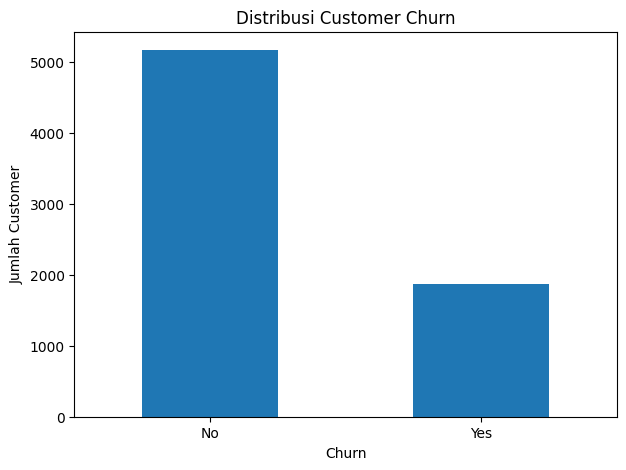

<Figure size 800x500 with 0 Axes>

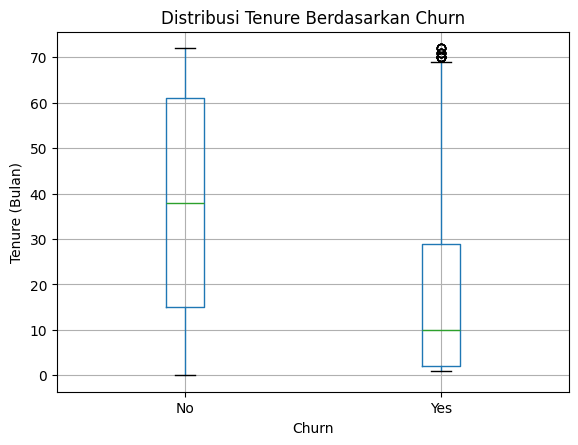

In [13]:
plt.figure(figsize=(7, 5))

churn_count.plot(kind='bar')

plt.title('Distribusi Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(8, 5))

df.boxplot(
    column='tenure',
    by='Churn'
)

plt.title('Distribusi Tenure Berdasarkan Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (Bulan)')
plt.show()

### 4.2 Contract vs Churn

Analisis ini melihat proporsi churn berdasarkan jenis kontrak pelanggan, yaitu Month-to-month, One year, dan Two year.

Tujuannya adalah mengetahui apakah terdapat pola perbedaan churn berdasarkan jenis kontrak.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


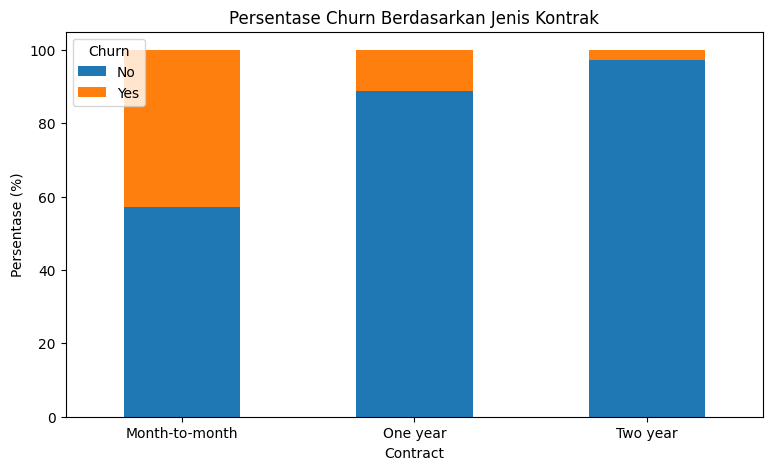

In [14]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn.round(2))

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Persentase Churn Berdasarkan Jenis Kontrak')
plt.xlabel('Contract')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.3 Tenure vs Churn

Tenure merupakan lama pelanggan menggunakan layanan. Variabel ini dikelompokkan ke dalam beberapa rentang agar pola churn berdasarkan lama berlangganan lebih mudah diamati.

`TenureGroup` dibuat khusus untuk kebutuhan EDA dan tidak digunakan sebagai fitur model karena variabel `tenure` asli tetap digunakan.

Churn           No    Yes
TenureGroup              
1–12 bulan   52.56  47.44
13–24 bulan  71.29  28.71
25–48 bulan  79.61  20.39
49–72 bulan  90.49   9.51


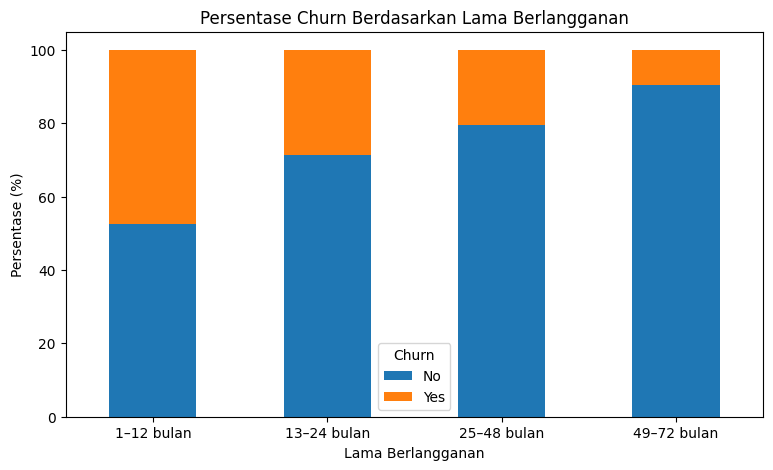

In [15]:
bins = [0, 12, 24, 48, 72]
labels = ['1–12 bulan', '13–24 bulan', '25–48 bulan', '49–72 bulan']

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

print(tenure_churn.round(2))

tenure_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Persentase Churn Berdasarkan Lama Berlangganan')
plt.xlabel('Lama Berlangganan')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.4 Monthly Charges vs Churn

Analisis ini membandingkan distribusi biaya bulanan antara pelanggan yang churn dan tidak churn.

Perbandingan mean, median, minimum, dan maksimum digunakan untuk melihat perbedaan karakteristik biaya antar kelompok.

        mean  median    min     max
Churn                              
No     61.27   64.43  18.25  118.75
Yes    74.44   79.65  18.85  118.35


<Figure size 800x500 with 0 Axes>

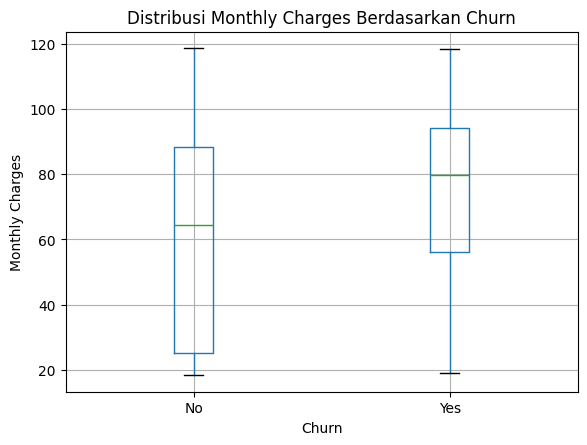

In [17]:
monthly_charges_churn = df.groupby('Churn')['MonthlyCharges'].agg(
    ['mean', 'median', 'min', 'max']
)

print(monthly_charges_churn.round(2))

plt.figure(figsize=(8, 5))

df.boxplot(
    column='MonthlyCharges',
    by='Churn'
)

plt.title('Distribusi Monthly Charges Berdasarkan Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### 4.5 Internet Service vs Churn

Analisis ini melihat proporsi churn berdasarkan jenis layanan internet yang digunakan pelanggan.

Hasil EDA digunakan sebagai insight eksploratif untuk memahami pola data, bukan sebagai bukti hubungan sebab-akibat.

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


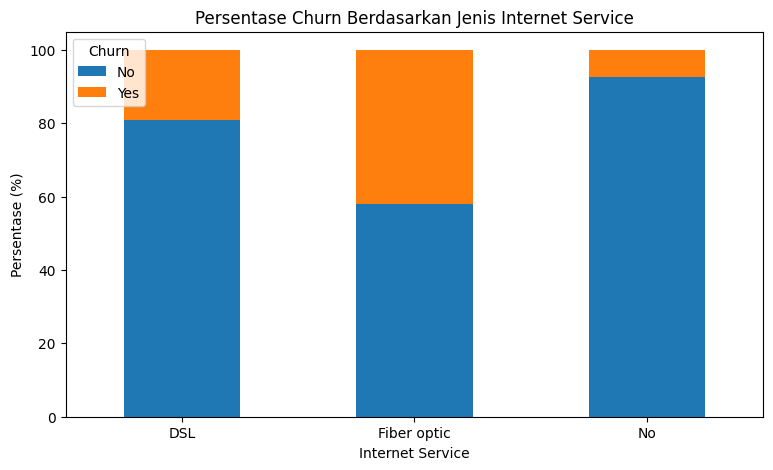

In [18]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))

internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Persentase Churn Berdasarkan Jenis Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

## 5. Final Data Validation

Sebelum memasuki tahap pemodelan, dilakukan pemeriksaan akhir terhadap missing value, duplicate, dan tipe data.

Tahap ini memastikan data hasil cleaning berada dalam kondisi yang sesuai untuk feature engineering dan pemodelan.

In [19]:
print("=== MISSING VALUE ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ===")
print("Jumlah duplicate:", df.duplicated().sum())

print("\n=== DATA TYPE ===")
print(df.dtypes)

=== MISSING VALUE ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureGroup         0
dtype: int64

=== DUPLICATE ===
Jumlah duplicate: 0

=== DATA TYPE ===
customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies  

## 6. Feature Engineering

Pada tahap ini target `Churn` diubah dari kategori menjadi numerik:
- `No` → 0
- `Yes` → 1

`customerID` dihapus karena hanya merupakan identifier pelanggan dan tidak memiliki informasi prediktif yang relevan. `TenureGroup` juga dihapus karena hanya digunakan untuk EDA, sedangkan `tenure` asli tetap digunakan sebagai fitur numerik.

Setelah tahap ini, data memiliki fitur yang siap dipisahkan menjadi predictor dan target.

In [20]:
# ==========================================
# FEATURE ENGINEERING & DATA PREPROCESSING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 1. Mengubah target Churn menjadi numerik
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

# 2. Menghapus identifier dan variabel yang hanya digunakan untuk EDA
df_model = df.drop(
    columns=['customerID', 'TenureGroup']
).copy()

# 3. Memisahkan fitur (X) dan target (y)
X = df_model.drop(columns='Churn')
y = df_model['Churn']

# 4. Menentukan fitur numerik dan kategorikal
numeric_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# 5. Preprocessing
# Numerik → StandardScaler
# Kategorikal → One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ), categorical_features)
    ]
)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# HASIL
# ==========================================

print("=== DATA MODELING ===")
print("Jumlah data       :", len(df_model))
print("Jumlah fitur awal :", X.shape[1])
print("Data training     :", X_train.shape[0])
print("Data testing      :", X_test.shape[0])

print("\n=== TARGET ===")
print(y.value_counts())
print("\nProporsi target:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\n=== FITUR NUMERIK ===")
print(numeric_features)

print("\n=== FITUR KATEGORIKAL ===")
print(categorical_features)

=== DATA MODELING ===
Jumlah data       : 7043
Jumlah fitur awal : 19
Data training     : 5634
Data testing      : 1409

=== TARGET ===
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporsi target:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

=== FITUR NUMERIK ===
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

=== FITUR KATEGORIKAL ===
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Feature and Target Separation

Dataset dipisahkan menjadi:
- `X` sebagai kumpulan variabel prediktor atau karakteristik pelanggan.
- `y` sebagai target yang ingin diprediksi, yaitu status churn.

Pemisahan ini menjadi dasar untuk proses train-test split dan pembangunan model klasifikasi.

In [21]:
# ==========================================
# MODEL DEVELOPMENT
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 1. Mendefinisikan model
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
}

# 2. Membuat pipeline untuk setiap model
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

# 3. Training seluruh model
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} berhasil ditraining.")

print("\nSemua model berhasil dibuat dan ditraining.")

Logistic Regression berhasil ditraining.
Decision Tree berhasil ditraining.
Random Forest berhasil ditraining.
XGBoost berhasil ditraining.

Semua model berhasil dibuat dan ditraining.


## 8. Data Preprocessing

Dataset memiliki fitur numerik dan kategorikal sehingga diperlukan preprocessing.

Fitur numerik diproses menggunakan `StandardScaler`, sedangkan fitur kategorikal diubah menjadi bentuk numerik menggunakan `OneHotEncoder`.

Preprocessing ditempatkan dalam `Pipeline`/`ColumnTransformer` agar transformasi dilakukan secara konsisten dan parameter preprocessing tidak dipelajari dari data testing, sehingga membantu mencegah data leakage.

In [22]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []
confusion_matrices = {}

for name, pipeline in pipelines.items():

    # Prediksi kelas
    y_pred = pipeline.predict(X_test)

    # Probabilitas kelas 1 untuk ROC-AUC
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Menghitung metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Menyimpan confusion matrix
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

# Membuat tabel hasil
results_df = pd.DataFrame(results)

# Membulatkan angka
results_display = results_df.copy()
metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

results_display[metric_columns] = (
    results_display[metric_columns] * 100
).round(2)

print("=== PERBANDINGAN PERFORMA MODEL ===")
display(results_display)

=== PERBANDINGAN PERFORMA MODEL ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.70,66.04,56.15,60.69,84.22
1,Decision Tree,79.42,63.12,54.01,58.21,82.67
2,Random Forest,78.99,62.91,50.80,56.21,82.59
3,XGBoost,80.48,66.89,52.41,58.77,84.62


## 9. Train-Test Split

Data dibagi menjadi data training dan testing dengan proporsi 80:20.

Data training digunakan untuk membangun model, sedangkan data testing digunakan untuk mengukur performa model pada data yang belum digunakan saat training.

`stratify=y` digunakan agar proporsi kelas Churn tetap terjaga pada data training dan testing.


Logistic Regression
              precision    recall  f1-score   support

 Tidak Churn     0.8497    0.8957    0.8721      1035
       Churn     0.6604    0.5615    0.6069       374

    accuracy                         0.8070      1409
   macro avg     0.7550    0.7286    0.7395      1409
weighted avg     0.7994    0.8070    0.8017      1409


Decision Tree
              precision    recall  f1-score   support

 Tidak Churn     0.8421    0.8860    0.8635      1035
       Churn     0.6312    0.5401    0.5821       374

    accuracy                         0.7942      1409
   macro avg     0.7367    0.7130    0.7228      1409
weighted avg     0.7861    0.7942    0.7888      1409


Random Forest
              precision    recall  f1-score   support

 Tidak Churn     0.8338    0.8918    0.8618      1035
       Churn     0.6291    0.5080    0.5621       374

    accuracy                         0.7899      1409
   macro avg     0.7315    0.6999    0.7120      1409
weighted avg     0.7795

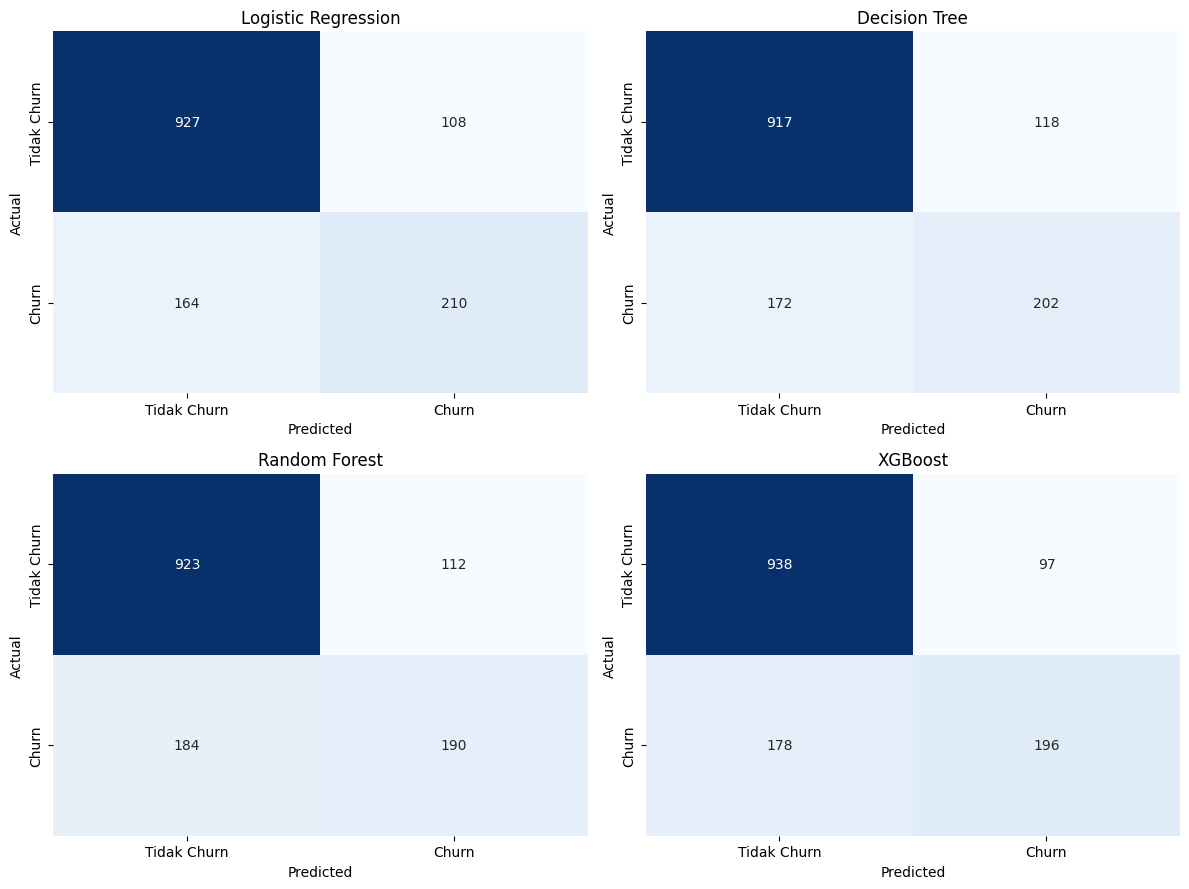

In [25]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Tidak Churn', 'Churn'],
            digits=4
        )
    )
# ==========================================
# CONFUSION MATRIX
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (name, cm) in zip(axes.ravel(), confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    ax.set_xticklabels(['Tidak Churn', 'Churn'])
    ax.set_yticklabels(['Tidak Churn', 'Churn'])

plt.tight_layout()
plt.show()

## 10. Model Development

Empat algoritma klasifikasi digunakan untuk membandingkan performa prediksi customer churn:

1. **Logistic Regression** sebagai baseline model dan model yang relatif mudah diinterpretasikan.
2. **Decision Tree** sebagai model berbasis aturan percabangan.
3. **Random Forest** sebagai ensemble yang menggabungkan banyak Decision Tree.
4. **XGBoost** sebagai algoritma boosting yang membangun model secara bertahap untuk memperbaiki kesalahan prediksi.

Setiap model dikombinasikan dengan preprocessing melalui Pipeline.

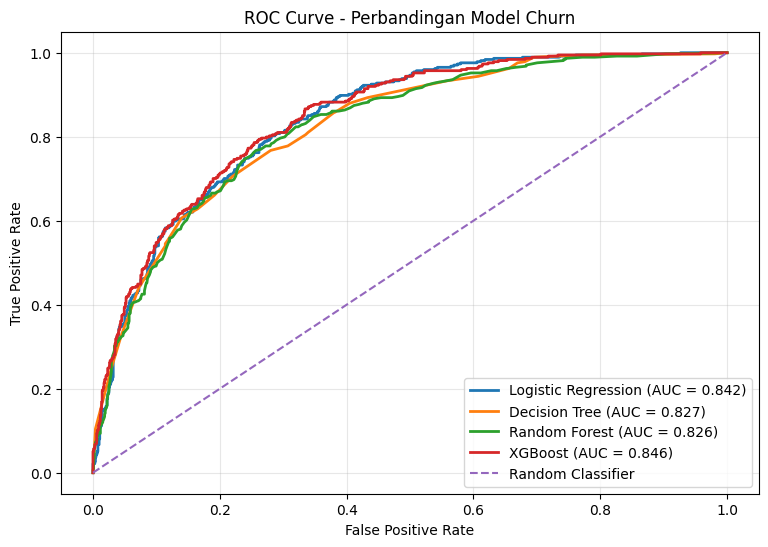

In [26]:
# ==========================================
# ROC CURVE COMPARISON
# ==========================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

for name, pipeline in pipelines.items():

    # Probabilitas Churn = 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

# Garis random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model Churn')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Model Evaluation

Model dievaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

- **Accuracy** menunjukkan proporsi seluruh prediksi yang benar.
- **Precision** menunjukkan ketepatan prediksi pada kelas churn.
- **Recall** menunjukkan kemampuan model menemukan pelanggan yang benar-benar churn.
- **F1-Score** merupakan keseimbangan antara Precision dan Recall.
- **ROC-AUC** menunjukkan kemampuan model membedakan kelas churn dan tidak churn pada berbagai threshold.

Karena tujuan project adalah mendeteksi customer churn, Recall dan F1-Score kelas churn menjadi metrik penting selain Accuracy dan ROC-AUC.

=== 15 FITUR PALING BERPENGARUH ===


,Feature,Coefficient
25,cat__Contract_Two year,-1.326384
1,num__tenure,-1.250481
10,cat__InternetService_Fiber optic,1.182298
24,cat__Contract_One year,-0.686597
3,num__TotalCharges,0.523110
7,cat__PhoneService_Yes,-0.505143
2,num__MonthlyCharges,-0.470779
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065


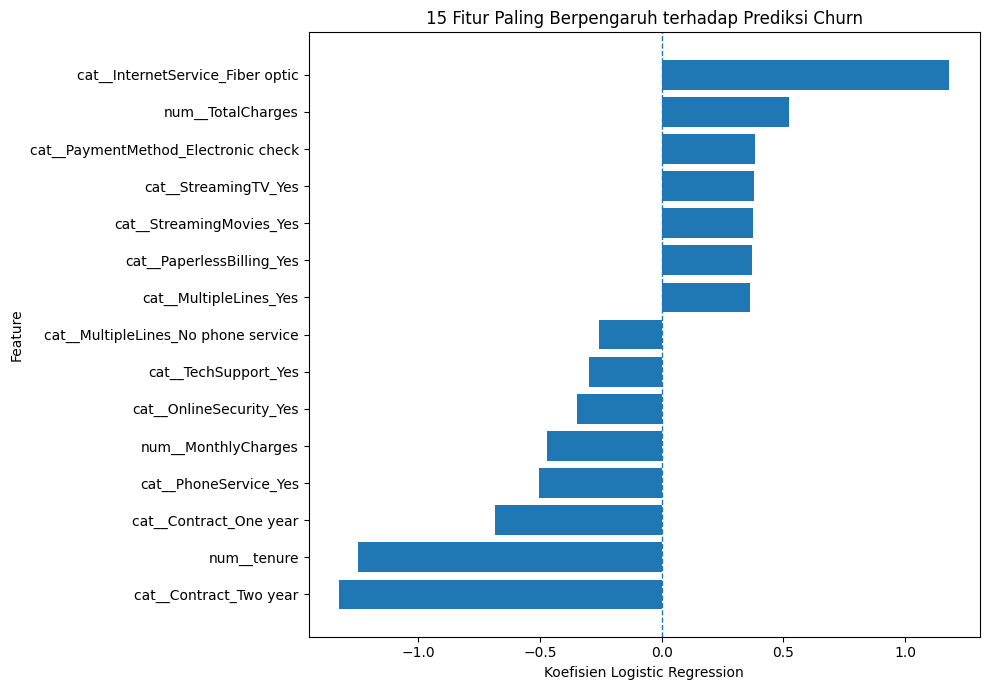

In [27]:
# ==========================================
# FEATURE IMPORTANCE - LOGISTIC REGRESSION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mengambil pipeline Logistic Regression
logistic_pipeline = pipelines['Logistic Regression']

# Mengambil hasil preprocessing
preprocessor_fitted = logistic_pipeline.named_steps['preprocessor']

# Mengambil model Logistic Regression
logistic_model = logistic_pipeline.named_steps['model']

# Mendapatkan nama fitur setelah One-Hot Encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Mengambil koefisien model
coefficients = logistic_model.coef_[0]

# Membuat DataFrame feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Mengurutkan berdasarkan nilai absolut koefisien
feature_importance = feature_importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

# Menampilkan 15 fitur paling berpengaruh
print("=== 15 FITUR PALING BERPENGARUH ===")

display(
    feature_importance[
        ['Feature', 'Coefficient']
    ].head(15)
)

# ==========================================
# VISUALISASI
# ==========================================

top_features = feature_importance.head(15).sort_values(
    'Coefficient'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Koefisien Logistic Regression')
plt.ylabel('Feature')
plt.title('15 Fitur Paling Berpengaruh terhadap Prediksi Churn')

plt.tight_layout()
plt.show()

### 11.1 Classification Report

Classification report digunakan untuk melihat performa model secara lebih rinci pada masing-masing kelas, yaitu Tidak Churn dan Churn.

Selain accuracy, perhatian diberikan pada precision, recall, dan F1-score kelas Churn karena kesalahan dalam mendeteksi pelanggan yang benar-benar churn merupakan bagian penting dari permasalahan bisnis.

In [28]:
# ==========================================
# ODDS RATIO - LOGISTIC REGRESSION
# ==========================================

# Menghitung Odds Ratio
feature_importance['Odds_Ratio'] = np.exp(
    feature_importance['Coefficient']
)

# Membuat tabel interpretasi
odds_ratio_df = feature_importance[
    ['Feature', 'Coefficient', 'Odds_Ratio']
].copy()

# Urutkan berdasarkan Odds Ratio
odds_ratio_df = odds_ratio_df.sort_values(
    'Odds_Ratio',
    ascending=False
)

print("=== ODDS RATIO FITUR ===")

display(
    odds_ratio_df.head(15).round(3)
)

# ==========================================
# FITUR YANG MENINGKATKAN ODDS CHURN
# ==========================================

print("\n=== FITUR DENGAN ODDS CHURN LEBIH TINGGI ===")

display(
    odds_ratio_df[
        odds_ratio_df['Odds_Ratio'] > 1
    ].head(10).round(3)
)

# ==========================================
# FITUR YANG MENURUNKAN ODDS CHURN
# ==========================================

print("\n=== FITUR DENGAN ODDS CHURN LEBIH RENDAH ===")

display(
    odds_ratio_df[
        odds_ratio_df['Odds_Ratio'] < 1
    ].sort_values('Odds_Ratio').head(10).round(3)
)

=== ODDS RATIO FITUR ===


,Feature,Coefficient,Odds_Ratio
10,cat__InternetService_Fiber optic,1.182,3.262
3,num__TotalCharges,0.523,1.687
28,cat__PaymentMethod_Electronic check,0.384,1.468
21,cat__StreamingTV_Yes,0.378,1.459
23,cat__StreamingMovies_Yes,0.376,1.457
26,cat__PaperlessBilling_Yes,0.371,1.450
9,cat__MultipleLines_Yes,0.362,1.437
29,cat__PaymentMethod_Mailed check,0.075,1.078
0,num__SeniorCitizen,0.055,1.056
17,cat__DeviceProtection_Yes,0.035,1.036



=== FITUR DENGAN ODDS CHURN LEBIH TINGGI ===


,Feature,Coefficient,Odds_Ratio
10,cat__InternetService_Fiber optic,1.182,3.262
3,num__TotalCharges,0.523,1.687
28,cat__PaymentMethod_Electronic check,0.384,1.468
21,cat__StreamingTV_Yes,0.378,1.459
23,cat__StreamingMovies_Yes,0.376,1.457
26,cat__PaperlessBilling_Yes,0.371,1.450
9,cat__MultipleLines_Yes,0.362,1.437
29,cat__PaymentMethod_Mailed check,0.075,1.078
0,num__SeniorCitizen,0.055,1.056
17,cat__DeviceProtection_Yes,0.035,1.036



=== FITUR DENGAN ODDS CHURN LEBIH RENDAH ===


,Feature,Coefficient,Odds_Ratio
25,cat__Contract_Two year,-1.326,0.265
1,num__tenure,-1.250,0.286
24,cat__Contract_One year,-0.687,0.503
7,cat__PhoneService_Yes,-0.505,0.603
2,num__MonthlyCharges,-0.471,0.625
13,cat__OnlineSecurity_Yes,-0.350,0.705
19,cat__TechSupport_Yes,-0.298,0.743
8,cat__MultipleLines_No phone service,-0.257,0.774
6,cat__Dependents_Yes,-0.225,0.799
20,cat__StreamingTV_No internet service,-0.173,0.841


### 11.2 Confusion Matrix

Confusion Matrix digunakan untuk mengetahui jenis kesalahan klasifikasi yang dihasilkan model.

Matriks terdiri dari:
- **True Positive (TP)**: aktual churn dan diprediksi churn.
- **True Negative (TN)**: aktual tidak churn dan diprediksi tidak churn.
- **False Positive (FP)**: aktual tidak churn tetapi diprediksi churn.
- **False Negative (FN)**: aktual churn tetapi diprediksi tidak churn.

Dalam kasus churn, False Negative penting diperhatikan karena menunjukkan pelanggan churn yang tidak berhasil terdeteksi.

In [29]:
# ==========================================
# CUSTOMER CHURN PREDICTION
# ==========================================

# Contoh customer baru
customer_baru = pd.DataFrame({
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [5],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [90.00],
    'TotalCharges': [450.00]
})

# Prediksi
prediksi = logistic_pipeline.predict(customer_baru)

# Probabilitas churn
probabilitas = logistic_pipeline.predict_proba(customer_baru)[0, 1]

# Menentukan hasil
hasil_prediksi = 'Churn' if prediksi[0] == 1 else 'Tidak Churn'

print("=== CUSTOMER CHURN PREDICTION ===")
print(f"Prediksi          : {hasil_prediksi}")
print(f"Probabilitas Churn: {probabilitas:.2%}")

# Interpretasi sederhana
if probabilitas >= 0.5:
    print("Interpretasi      : Customer terindikasi memiliki risiko churn.")
else:
    print("Interpretasi      : Customer terindikasi tidak churn.")

=== CUSTOMER CHURN PREDICTION ===
Prediksi          : Churn
Probabilitas Churn: 76.47%
Interpretasi      : Customer terindikasi memiliki risiko churn.


### 11.3 ROC Curve

ROC Curve digunakan untuk membandingkan kemampuan model dalam membedakan pelanggan churn dan tidak churn pada berbagai threshold.

ROC-AUC merangkum kemampuan diskriminasi tersebut. Nilai yang lebih tinggi menunjukkan kemampuan membedakan kedua kelas yang lebih baik secara keseluruhan.

In [30]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

import joblib
import os

# Membuat folder untuk menyimpan model
model_path = '/content/drive/MyDrive/Project/Model'
os.makedirs(model_path, exist_ok=True)

# Menyimpan pipeline Logistic Regression
final_model_path = os.path.join(
    model_path,
    'customer_churn_logistic_regression.pkl'
)

joblib.dump(
    logistic_pipeline,
    final_model_path
)

print("Model berhasil disimpan!")
print("Lokasi:", final_model_path)

# Mengecek ukuran file
file_size = os.path.getsize(final_model_path) / 1024

print(f"Ukuran file: {file_size:.2f} KB")

Model berhasil disimpan!
Lokasi: /content/drive/MyDrive/Project/Model/customer_churn_logistic_regression.pkl
Ukuran file: 7.80 KB


## 15. Business Insights

Berdasarkan hasil EDA dan pemodelan, beberapa karakteristik menunjukkan pola yang berkaitan dengan customer churn.

1. Pelanggan dengan kontrak **Month-to-month** memiliki proporsi churn yang lebih tinggi dibandingkan kontrak One year dan Two year.
2. Pelanggan dengan **tenure lebih pendek** memiliki proporsi churn yang lebih tinggi pada dataset.
3. Pelanggan yang mengalami churn memiliki rata-rata dan median **MonthlyCharges** yang lebih tinggi.
4. Kategori **Fiber optic** memiliki proporsi churn yang lebih tinggi dibandingkan kategori InternetService lainnya.
5. Pada Logistic Regression, fitur seperti jenis kontrak, tenure, jenis layanan internet, dan metode pembayaran memiliki kontribusi terhadap prediksi churn.

Insight tersebut dapat digunakan sebagai dasar untuk mengidentifikasi pelanggan yang memiliki probabilitas churn lebih tinggi dan mendukung perancangan strategi retensi pelanggan.

## 16. Conclusion

Project ini berhasil membangun model Machine Learning untuk memprediksi customer churn menggunakan dataset Telco Customer Churn.

Proses dilakukan secara end-to-end mulai dari data loading, data understanding, data cleaning, exploratory data analysis, feature engineering, preprocessing, train-test split, pengembangan empat model klasifikasi, evaluasi model, interpretasi fitur, hingga simulasi prediksi customer baru.

Berdasarkan hasil pengujian, Logistic Regression memperoleh Accuracy sebesar **80,70%**, Precision kelas Churn sebesar **66,04%**, Recall sebesar **56,15%**, F1-Score sebesar **60,69%**, dan ROC-AUC sebesar **84,22%**. XGBoost memperoleh ROC-AUC sebesar **84,62%**.

Pada simulasi customer baru, Logistic Regression menghasilkan prediksi **Churn** dengan probabilitas sebesar **76,47%**.

Hasil ini menunjukkan bagaimana Machine Learning dapat diterapkan untuk mengidentifikasi pelanggan yang berpotensi mengalami churn berdasarkan karakteristik pelanggan dan layanan yang digunakan.